$$
\begin{array}{l}
\quad\quad\quad \textbf{I consider the 2 Years (2Y) Bond Yield because the market Interest rate expectations} \\
\quad\quad\quad \textbf{trigger the bond price moves and when bond price is up the yield is down, if bond price} \\
\quad\quad\quad \textbf{is down the yield is up}, \text{ bond prices move because of buying and selling in the market.} \\[1em]
\quad\quad\quad \text{Interest rates are a primary driver of currency prices because they dictate the flow of global} \\
\quad\quad\quad \text{capital, acting as a reward for investors and a cost for borrowers. Generally, } \textbf{higher interest} \\
\quad\quad\quad \textbf{rates strengthen a currency}, \text{ while lower interest rates weaken it. Currency rates react more} \\
\quad\quad\quad \text{to the expectations of the future rates than to the current ones.} \\[1em]
\quad\quad\quad \text{The 2Y yield reflects in real time } \textbf{what the market expects} \text{ central banks to do in the next 2} \\
\quad\quad\quad \text{years.} \\[1em]
\quad\quad\quad \text{So, the point is to measure the } \textbf{change in the 2Y yields} \text{ and not the level and the } \textbf{spread} \\
\quad\quad\quad \textbf{between the US one and the German one} \text{ (the German 2Y yield is the most important for the} \\
\quad\quad\quad \text{euro currency). And we must check if the move in this spread (} \textbf{widening or narrowing} \text{)} \\
\quad\quad\quad \text{reflects in a move of the EURUSD rate.} \\[1em]
\quad\quad\quad \text{In this purpose it is wise to } \textbf{normalize the data before analysis}. \text{ The economic data and} \\
\quad\quad\quad \text{political events that move the yields can be represented on a weekly basis for this reason I} \\
\quad\quad\quad \text{have chosen to average the data with a } \textbf{5 days Mobile Average}. \\[1em]
\quad\quad\quad \text{I will check to confirm any } \textbf{correlation between spread moves and EURUSD moves}. \\[2em]
\quad\quad\quad \textbf{Detailed representation of the 2 years yields importance} \\[1em]
\quad\quad\quad \textbf{The 2Y yield changes:} \\[1em]
\quad\quad\quad - \ \textbf{Continuously} \\[0.5em]
\quad\quad\quad\quad \bullet \ \text{During market hours (like a stock)} \\[1em]
\quad\quad\quad - \ \textbf{Abruptly (key moments)} \\[0.5em]
\quad\quad\quad\quad \bullet \ \text{Economic indicators releases (scheduled)} \\
\quad\quad\quad\quad \bullet \ \text{Central bank announcements (scheduled)} \\
\quad\quad\quad\quad \bullet \ \text{Unexpected news (unscheduled)} \\[1em]
\quad\quad\quad - \ \text{At } \textbf{specific times} \text{, yields can move } \textbf{VERY fast:} \\[0.5em]
\quad\quad\quad\quad \bullet \ \text{Inflation (CPI, Core PCE)} \\
\quad\quad\quad\quad \bullet \ \text{Jobs (NFP, unemployment)} \\
\quad\quad\quad\quad \bullet \ \text{GDP} \\[1em]
\quad\quad\quad \textbf{Example:} \\[0.5em]
\quad\quad\quad\quad \bullet \ \text{Strong US inflation } \rightarrow \text{ Fed may hike } \rightarrow \ \textbf{US 2Y} \uparrow \\
\quad\quad\quad\quad \bullet \ \text{Weak data } \rightarrow \text{ cuts expected } \rightarrow \ \textbf{US 2Y} \downarrow \\[0.5em]
\quad\quad\quad \text{These happen at } \textbf{exact release times} \text{ (e.g., 14:30 CET for US data)} \\[2em]
\quad\quad\quad \textbf{Other determing factors for the 2Y Yield:} \\[1em]
\quad\quad\quad \textbf{Central bank communication} \\[0.5em]
\quad\quad\quad \text{Huge impact when:} \\[0.5em]
\quad\quad\quad\quad \bullet \ \text{Fed / ECB } \textbf{rate decisions} \\
\quad\quad\quad\quad \bullet \ \text{Speeches from central bankers} \\[0.5em]
\quad\quad\quad \text{One sentence can move the 2Y instantly} \\[1.5em]
\quad\quad\quad \textbf{Market sentiment / risk} \\[0.5em]
\quad\quad\quad\quad \bullet \ \text{Crisis } \rightarrow \text{ investors buy bonds } \rightarrow \text{ yield } \downarrow \\
\quad\quad\quad\quad \bullet \ \text{Risk-on } \rightarrow \text{ sell bonds } \rightarrow \text{ yield } \uparrow \\[1.5em]
\end{array}
$$

In [59]:
# Analysis of the relation SPREAD 2Y Yields and the FX Rate EUR/USD
# We will try to see whether there is some correlation and how it is move and the degree of it 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [60]:
spread = pd.read_csv("data/US_DE_2Y_spread.csv")
eurusd = pd.read_csv("data/EURUSD_worked.csv")

In [61]:
eurusd.columns = ["Date", "EURUSD"]
spread["Date"] = pd.to_datetime(spread["Date"])
spread["Date"] = pd.to_datetime(eurusd["Date"])
eurusd["EURUSD"]=eurusd["EURUSD"].astype(float)
# to assure the same date format for the boths datasets
for dts in [spread, eurusd]:
    dts["Date"]=pd.to_datetime(dts["Date"])

In [62]:

ds_merged=pd.merge(spread, eurusd, on="Date", how="inner")
ds_merged=ds_merged.sort_values("Date").reset_index(drop=True)

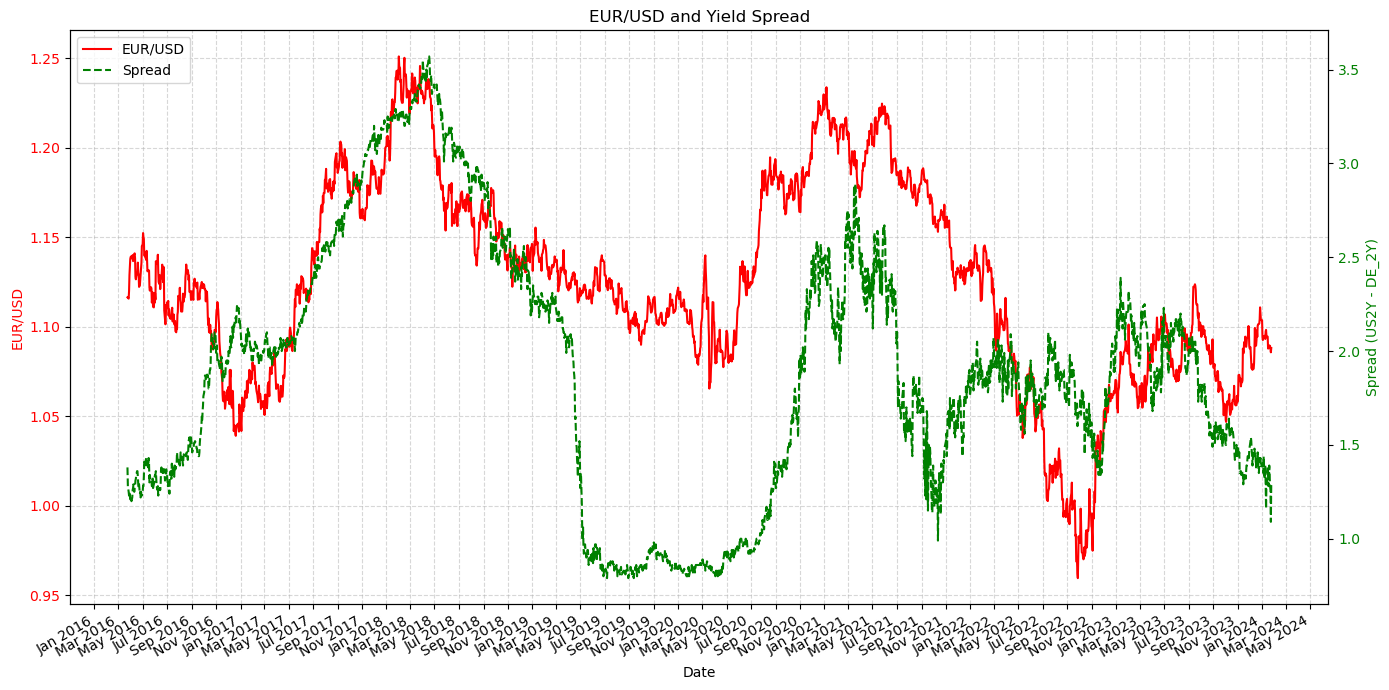

In [63]:
# Make sure Date is in datetime format
# Create figure
fig, ax1 = plt.subplots(figsize=(14,7))

ax1.plot(ds_merged["Date"], ds_merged["EURUSD"], color="red", linewidth=1.5, label="EUR/USD")
ax1.set_xlabel("Date")
ax1.set_ylabel("EUR/USD", color='red')
ax1.tick_params(axis="y", labelcolor='red')
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

ax2=ax1.twinx()
ax2.plot(ds_merged["Date"], ds_merged["Spread"], color="green", linestyle="--", linewidth=1.5, label="Spread")
# Right axis: Spread
ax2.set_ylabel("Spread (US2Y - DE_2Y)", color="green")
ax2.tick_params(axis="y", labelcolor="green")

plt.title("EUR/USD and Yield Spread")
ax1.grid(True, linestyle="--", alpha=0.5)

lines1,labels1=ax1.get_legend_handles_labels()
lines2, labels2=ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc="upper left")

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [64]:
ds_merged["EURUSD"].corr(ds_merged["Spread"])

np.float64(0.4618607692868437)

$$
\begin{array}{l}
\quad\quad\quad \text{This graph shows that the spread yields and the FX rate are } \textbf{positively correlated} \\
\quad\quad\quad \text{The correlation between the yield spread and EUR/USD is approximately 0.46, }\\
\quad\quad\quad \text{indicating a moderate positive linear relationship.} \\
\quad\quad\quad \text{This is opposite of the hypothesis that they are negatively correlated.} \\[1em]
\quad\quad\quad \text{To reduce short-term noise and better capture underlying trends, I applied a } \textbf{5-day moving} \\
\quad\quad\quad \textbf{average}. \text{ This choice reflects the fact that macroeconomic effects are typically transmitted} \\
\quad\quad\quad \text{over several days rather than instantaneously.} \\[1em]
\quad\quad\quad \text{Finally, I normalized both the FX rate and the spread using } \textbf{Z-scores} \text{ in order to make} \\
\quad\quad\quad \text{them directly comparable, expressing each variable in terms of its deviation from its historical mean.} \\
\end{array}
$$

In [65]:
ds_merged["Spread_5D_AV"] = ds_merged["Spread"].rolling(30).mean()
ds_merged["EURUSD_5D_AV"] = ds_merged["EURUSD"].rolling(30).mean()

ds_merged = ds_merged.dropna()

ds_merged["Spread_Z"] = (ds_merged["Spread_5D_AV"] - ds_merged["Spread_5D_AV"].mean()) / ds_merged["Spread_5D_AV"].std()
ds_merged["EURUSD_Z"] = (ds_merged["EURUSD_5D_AV"] - ds_merged["EURUSD_5D_AV"].mean()) / ds_merged["EURUSD_5D_AV"].std()
# Remove rows with NaN only in the columns we need
ds_merged = ds_merged.dropna(subset=["Spread_Z", "EURUSD_Z"])

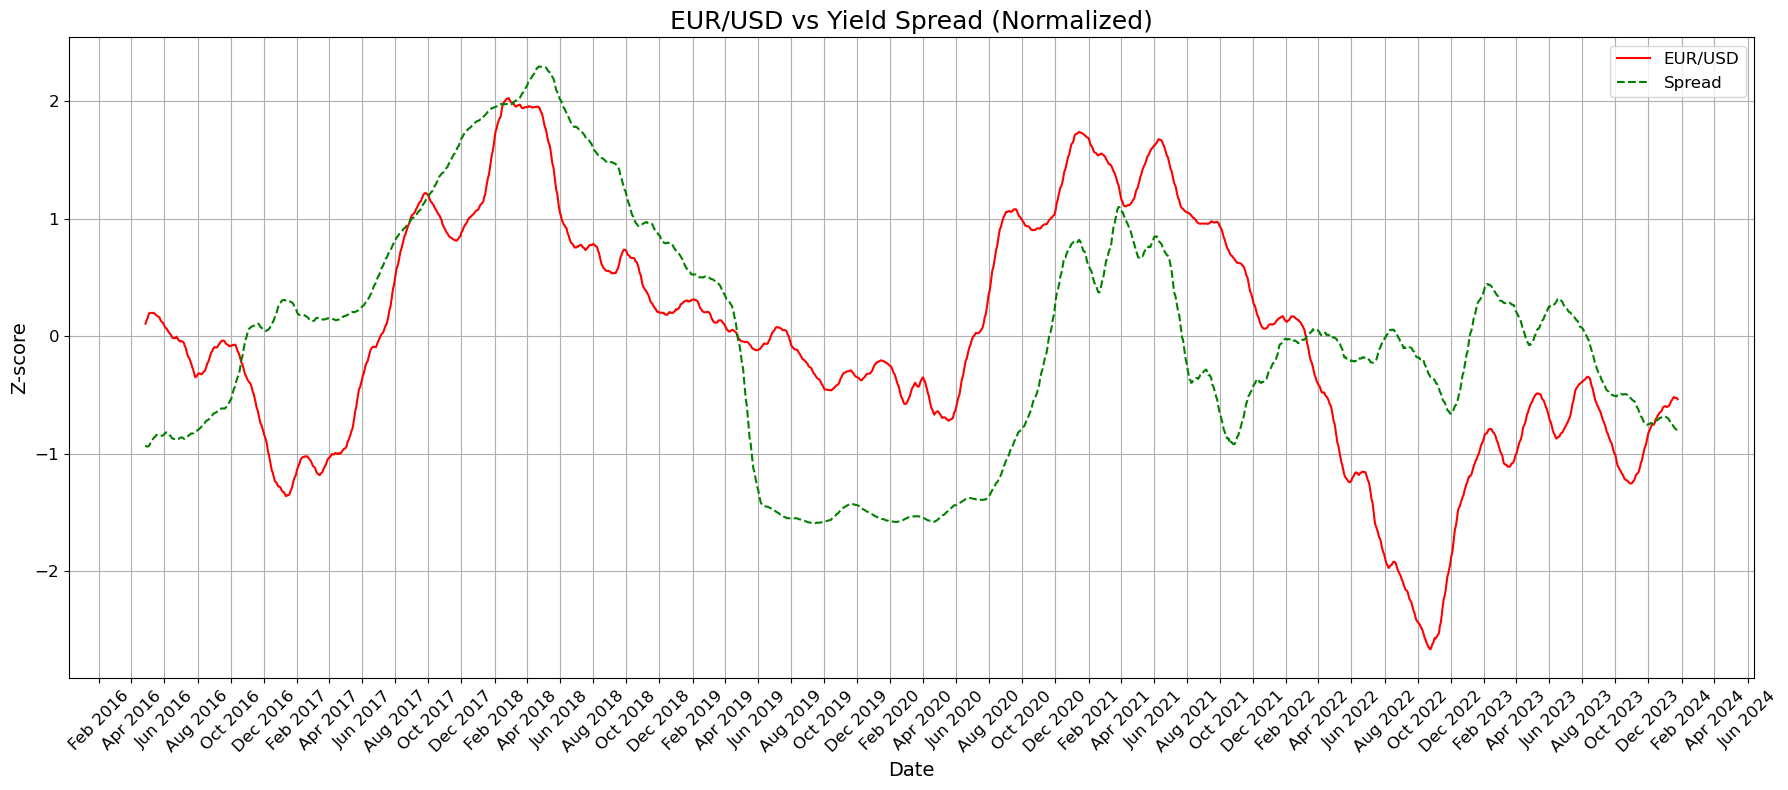

In [66]:

# --- Plot ---
fig, ax = plt.subplots(figsize=(18,8))

ax.plot(ds_merged["Date"], ds_merged["EURUSD_Z"], color="red", label="EUR/USD")
ax.plot(ds_merged["Date"], ds_merged["Spread_Z"], color="green", linestyle="dashed", label="Spread")


ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2)) 
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

plt.xticks(rotation=45, fontsize=12)
ax.tick_params(axis='y', labelsize=12)

ax.set_title("EUR/USD vs Yield Spread (Normalized)", fontsize=18)
ax.set_xlabel("Date", fontsize=14)
ax.set_ylabel("Z-score", fontsize=14)


ax.legend(fontsize=12)
ax.grid(True)

plt.tight_layout()
plt.show()

In [67]:
ds_merged["EURUSD_Z"].corr(ds_merged["Spread_Z"])

np.float64(0.4715171733999411)

$$
\begin{array}{l}
\quad\quad\quad \text{It appears that the correlation remains } \textbf{positive}. \\[1em]
\quad\quad\quad \text{To investigate whether EUR/USD reacts to changes in the yield spread with a delay,} \\
\quad\quad\quad \text{lags ranging from } \textbf{1 to 30 days} \text{ were tested.} \\
\end{array}
$$

In [68]:
for lag in range(1,30):
    corr = ds_merged["EURUSD_Z"].corr(ds_merged["Spread_Z"].shift(lag))
    print(f"Lag {lag}: {corr}")

Lag 1: 0.47085998280472235
Lag 2: 0.47017838306414483
Lag 3: 0.4694767820497174
Lag 4: 0.4687558693754242
Lag 5: 0.4680173771026433
Lag 6: 0.46725893193303275
Lag 7: 0.4664813498909181
Lag 8: 0.46568218276006673
Lag 9: 0.46486188753678387
Lag 10: 0.46402065174926305
Lag 11: 0.4631596158949862
Lag 12: 0.46227976013960537
Lag 13: 0.4613834740027795
Lag 14: 0.46047067879238046
Lag 15: 0.4595386569079063
Lag 16: 0.45858744335332924
Lag 17: 0.4576173388811314
Lag 18: 0.45662912623621243
Lag 19: 0.4556242863610286
Lag 20: 0.45460279215303784
Lag 21: 0.45356515763871763
Lag 22: 0.4525111816411656
Lag 23: 0.45144067562436724
Lag 24: 0.45035049458620635
Lag 25: 0.4492431467773292
Lag 26: 0.44811988928496593
Lag 27: 0.4469816704853012
Lag 28: 0.44582858452231117
Lag 29: 0.44466076568265134


$$
\begin{array}{l}
\quad\quad\quad \text{The correlation remains } \textbf{positive across all tested lags}, \text{ which contrasts with the theoretical} \\
\quad\quad\quad \text{expectation of a negative relationship between the yield spread and the EUR/USD exchange rate.} \\[1.5em]
\quad\quad\quad \text{One possible explanation is that the analysis is conducted over a } \textbf{long period (2016--2026)} \\
\quad\quad\quad \text{that includes multiple macroeconomic regimes, such as the COVID-19 crisis, geopolitical} \\
\quad\quad\quad \text{tensions, elections, and major economic shocks. These events introduce additional drivers} \\
\quad\quad\quad \text{of exchange rate movements beyond the yield spread.} \\[1.5em]
\quad\quad\quad \text{As a result, the relationship between the yield spread and EUR/USD is } \textbf{not stable over time} \\
\quad\quad\quad \text{and may vary depending on the prevailing economic environment.} \\[1.5em]
\quad\quad\quad \text{To address this issue, the sample period will be divided into } \textbf{shorter sub-periods}, \text{ allowing} \\
\quad\quad\quad \text{for a more precise analysis of the relationship under different macroeconomic conditions.} \\
\quad\quad\quad \text{This approach will also make it possible to incorporate other relevant factors, rather than} \\
\quad\quad\quad \text{relying solely on the yield spread.} \\
\end{array}
$$